In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform, color, util
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

import warnings
warnings.filterwarnings('ignore')

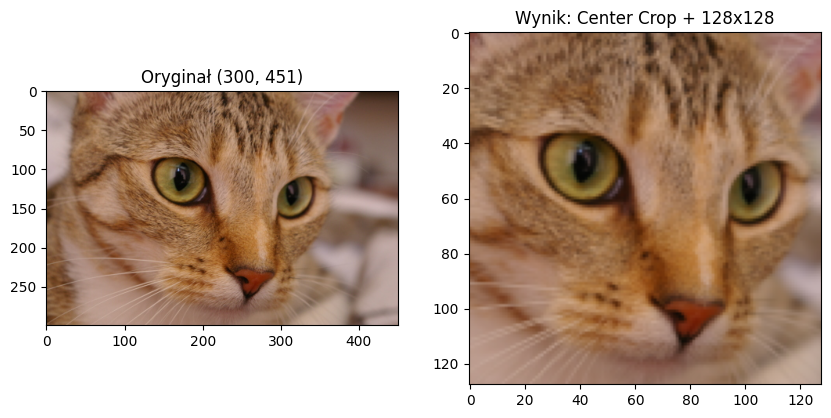

In [2]:



cat_image = data.chelsea() #

h, w, _ = cat_image.shape
min_dim = min(h, w)

offset = (w - h) // 2


cat_square = cat_image[:, offset:offset+h, :]


cat_final = transform.resize(cat_square, (128, 128))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(cat_image)
ax[0].set_title(f"Oryginał {cat_image.shape[:2]}")

ax[1].imshow(cat_final)
ax[1].set_title("Wynik: Center Crop + 128x128")

plt.show()

In [3]:
from skimage import data

image_raw = data.astronaut()

Po spłaszczeniu: (262144,)


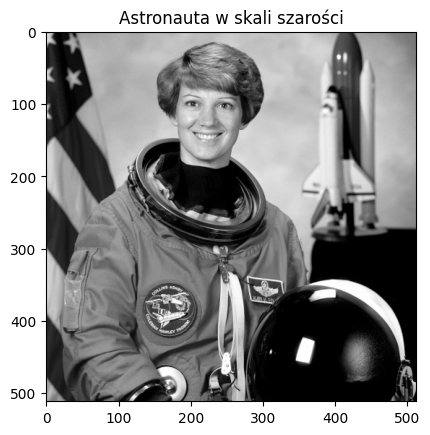

In [4]:
from skimage import color


img_gray = color.rgb2gray(image_raw)

img_flat = img_gray.flatten()
print(f"Po spłaszczeniu: {img_flat.shape}")

plt.imshow(img_gray, cmap='gray')
plt.title("Astronauta w skali szarości")
plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
img_2d = img_flat.reshape(1, -1)

img_std = scaler.fit_transform(img_2d)
print(f"Średnia po standaryzacji: {img_std.mean():.4f}")
print(f"Odchylenie standardowe po standaryzacji: {img_std.std():.4f}")

Średnia po standaryzacji: 0.0000
Odchylenie standardowe po standaryzacji: 0.0000


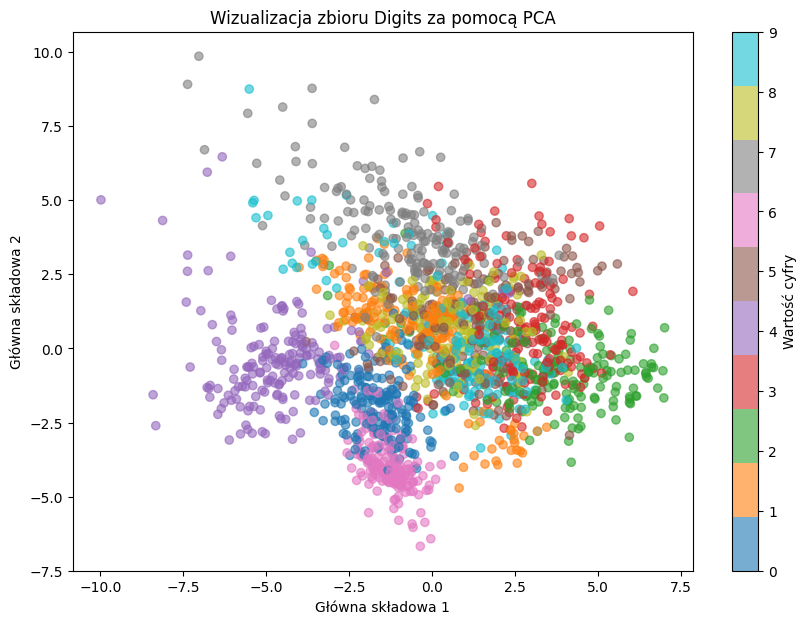

In [6]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


digits = load_digits()
X = digits.data
y = digits.target

X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Wartość cyfry')
plt.xlabel('Główna składowa 1')
plt.ylabel('Główna składowa 2')
plt.title('Wizualizacja zbioru Digits za pomocą PCA')
plt.show()

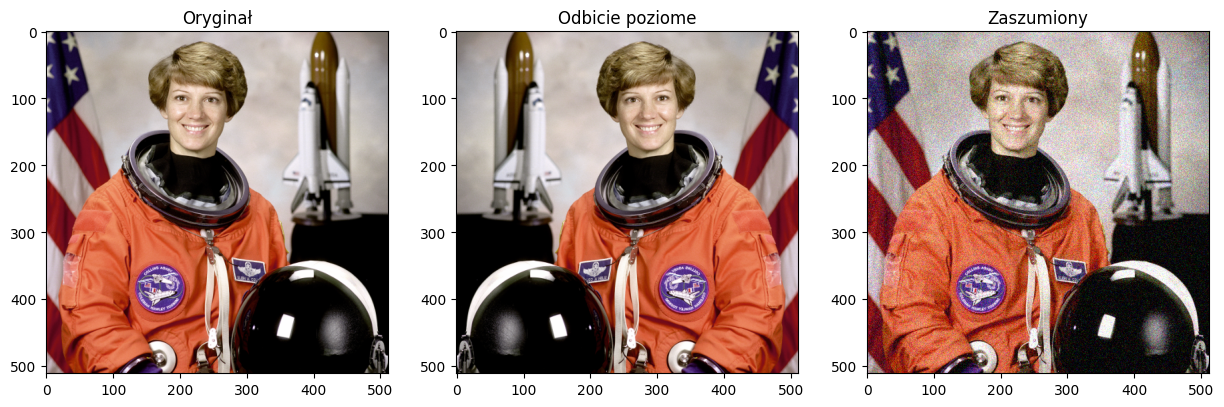

In [8]:
import matplotlib.pyplot as plt
from skimage import data, util


image_raw = data.astronaut()
image_flipped = image_raw[:, ::-1, :]

image_noisy = util.random_noise(image_raw)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image_raw)
ax[0].set_title("Oryginał")

ax[1].imshow(image_flipped)
ax[1].set_title("Odbicie poziome")

ax[2].imshow(image_noisy)
ax[2].set_title("Zaszumiony")

plt.show()

Liczba cech potrzebna do zachowania 90% wariancji: 21 (z oryginalnych 64)


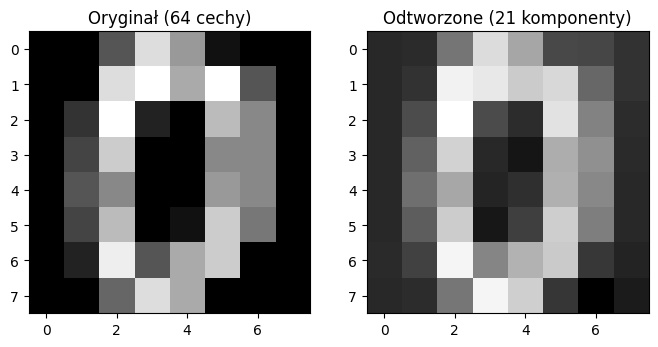

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


pca = PCA(n_components=0.90)


X_pca = pca.fit_transform(X)

n_kept = pca.n_components_
print(f"Liczba cech potrzebna do zachowania 90% wariancji: {n_kept} (z oryginalnych 64)")

X_recovered = pca.inverse_transform(X_pca)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(X[0].reshape(8, 8), cmap='gray')
ax[0].set_title("Oryginał (64 cechy)")

ax[1].imshow(X_recovered[0].reshape(8, 8), cmap='gray')
ax[1].set_title(f"Odtworzone ({n_kept} komponenty)")

plt.show()

In [12]:
import random
import os
from skimage import data, transform, color, io, util

def flip_or_not_to_flip(img, prob=0.5):
    if random.random() < prob:
        return img[:, ::-1, ...]
    return img

def gray_or_not_gray(img, prob=0.5):
    if random.random() < prob:
        if len(img.shape) == 3:
            return color.rgb2gray(img)
    return img

In [13]:
def preprocess_images(image_list, target_size=(128, 128), save_dir='output_images'):

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    processed_count = 0

    for idx, img in enumerate(image_list):
        h, w = img.shape[:2]

        if (h, w) != target_size:
            min_dim = min(h, w)
            start_h = (h - min_dim) // 2
            start_w = (w - min_dim) // 2
            img = img[start_h:start_h+min_dim, start_w:start_w+min_dim]

            img = transform.resize(img, target_size)

        img = flip_or_not_to_flip(img, prob=0.5)
        img = gray_or_not_gray(img, prob=0.5)

        save_img = util.img_as_ubyte(img)

        file_path = os.path.join(save_dir, f'processed_{idx}.png')
        io.imsave(file_path, save_img)
        processed_count += 1

    print(f"Przetworzono i zapisano {processed_count} obrazów w lokalizacji: {save_dir}")


img_names = ['rocket', 'astronaut', 'camera', 'cat', 'coffee']
loaded_images = []

for name in img_names:
    img_data = eval(f'data.{name}()')
    loaded_images.append(img_data)

preprocess_images(loaded_images, target_size=(128, 128), save_dir='moje_obrazy')

Przetworzono i zapisano 5 obrazów w lokalizacji: moje_obrazy
